# K-Nearest Neighbors (KNN Classifier)

In [1]:
# Step 1: Import the libraries needed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [2]:
# Step 2: Define dataset folder and load all images directly from class subfolders
base_dir = os.path.join("..", "results", "outputs")
if not os.path.exists(base_dir):
    base_dir = os.path.join("results", "outputs")

# Find all 7 class folders
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Found classes in dataset:")
for index, class_name in enumerate(classes):
    print(f"  Class {index}: {class_name}")

X_images = []
y_labels = []

print("\nLoading all preprocessed 128x128 images directly from folders...")
for class_index, class_name in enumerate(classes):
    folder_path = os.path.join(base_dir, class_name)
    all_files = os.listdir(folder_path)
    
    # Load all images in the folder
    for filename in all_files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            # Open 128x128 image and convert to grayscale
            img = Image.open(img_path).convert('L')
            # Turn image pixels into numbers between 0 and 1
            pixels = np.array(img, dtype=np.float32).flatten() / 255.0
            X_images.append(pixels)
            y_labels.append(class_index)
            
    print(f"  Loaded {len(all_files)} images from: {class_name}")

X = np.array(X_images)
y = np.array(y_labels)
print(f"\nTotal loaded images: {len(y)}")
print(f"Each image has {X.shape[1]} pixels (128x128 = 16384)")


Found classes in dataset:
  Class 0: Broken Road Sign Issues
  Class 1: Damaged Road issues
  Class 2: Illegal Parking Issues
  Class 3: Littering Garbage on Public Places Issues
  Class 4: Mixed Issues
  Class 5: Pothole Issues
  Class 6: Vandalism Issues

Loading all preprocessed 128x128 images directly from folders...


  Loaded 3331 images from: Broken Road Sign Issues


  Loaded 3331 images from: Damaged Road issues


  Loaded 3331 images from: Illegal Parking Issues


  Loaded 3331 images from: Littering Garbage on Public Places Issues


  Loaded 3331 images from: Mixed Issues


  Loaded 3331 images from: Pothole Issues


  Loaded 3331 images from: Vandalism Issues

Total loaded images: 23317
Each image has 16384 pixels (128x128 = 16384)


In [3]:
# Step 3: Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Apply PCA dimensionality reduction
# Raw images have 16,384 pixels, which is too many for traditional machine learning.
# PCA finds the 50 most important patterns that describe the image.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete! 50 components explain {variance:.2f}% of the image information.")


Training samples: 18653
Testing samples:  4664


PCA complete! 50 components explain 79.92% of the image information.


In [4]:
# Step 5: Train a baseline KNN model with K=5
knn_baseline = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn_baseline.fit(X_train_pca, y_train)

train_acc = accuracy_score(y_train, knn_baseline.predict(X_train_pca)) * 100
test_acc = accuracy_score(y_test, knn_baseline.predict(X_test_pca)) * 100

print("Baseline KNN Results (K=5):")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")


Baseline KNN Results (K=5):
Training Accuracy: 77.63%
Testing Accuracy:  66.34%


Testing different K values:


  When K = 1  -> Train Accuracy: 100.00%, Test Accuracy: 77.47% (Gap: 22.53%)


  When K = 3  -> Train Accuracy: 84.80%, Test Accuracy: 69.98% (Gap: 14.81%)


  When K = 5  -> Train Accuracy: 77.63%, Test Accuracy: 66.34% (Gap: 11.30%)


  When K = 7  -> Train Accuracy: 73.27%, Test Accuracy: 64.02% (Gap: 9.25%)


  When K = 11 -> Train Accuracy: 66.87%, Test Accuracy: 59.09% (Gap: 7.78%)


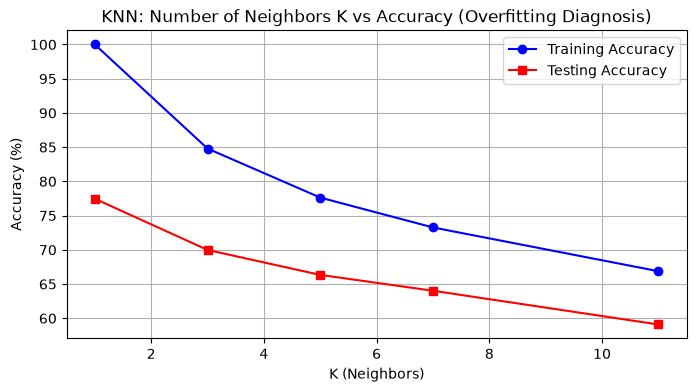

In [5]:
# Step 6: Hyperparameter tuning - Test different values of K
# K is the number of closest neighbors to check
# If K = 1, the model memorizes every sample (extreme overfitting)
# If K is too large, the model gets blurry and underfits
k_choices = [1, 3, 5, 7, 11]
train_scores = []
test_scores = []

print("Testing different K values:")
for k in k_choices:
    model = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    model.fit(X_train_pca, y_train)
    
    tr = accuracy_score(y_train, model.predict(X_train_pca)) * 100
    te = accuracy_score(y_test, model.predict(X_test_pca)) * 100
    
    train_scores.append(tr)
    test_scores.append(te)
    print(f"  When K = {k:<2} -> Train Accuracy: {tr:.2f}%, Test Accuracy: {te:.2f}% (Gap: {tr-te:.2f}%)")

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_choices, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(k_choices, test_scores, 's-', label='Testing Accuracy', color='red')
plt.title('KNN: Number of Neighbors K vs Accuracy (Overfitting Diagnosis)')
plt.xlabel('K (Neighbors)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# Step 7: Compare Distance Weighting (Uniform vs Distance-Weighted)
# In distance weighting, closer neighbors have a bigger vote
varieties = [
    ("Uniform + Euclidean", KNeighborsClassifier(n_neighbors=7, weights='uniform', metric='euclidean')),
    ("Distance-Weighted + Euclidean", KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')),
    ("Distance-Weighted + Manhattan", KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'))
]

print("Evaluating Weighting and Metric Varieties (at K=7):")
for name, clf in varieties:
    clf.fit(X_train_pca, y_train)
    te = accuracy_score(y_test, clf.predict(X_test_pca)) * 100
    f1 = f1_score(y_test, clf.predict(X_test_pca), average='macro')
    print(f"  {name:<30}: Test Accuracy = {te:.2f}%, Macro F1 = {f1:.4f}")


Evaluating Weighting and Metric Varieties (at K=7):


  Uniform + Euclidean           : Test Accuracy = 64.02%, Macro F1 = 0.6199


  Distance-Weighted + Euclidean : Test Accuracy = 70.97%, Macro F1 = 0.6959


  Distance-Weighted + Manhattan : Test Accuracy = 74.68%, Macro F1 = 0.7352


Classification Report:
                 precision    recall  f1-score   support

Broken Road Sig       0.80      0.58      0.67       666
Damaged Road is       0.81      0.71      0.76       666
Illegal Parking       0.87      0.98      0.93       666
Littering Garba       0.50      0.90      0.64       667
   Mixed Issues       0.71      0.98      0.82       666
 Pothole Issues       0.68      0.33      0.45       666
Vandalism Issue       0.82      0.48      0.61       667

       accuracy                           0.71      4664
      macro avg       0.74      0.71      0.70      4664
   weighted avg       0.74      0.71      0.70      4664



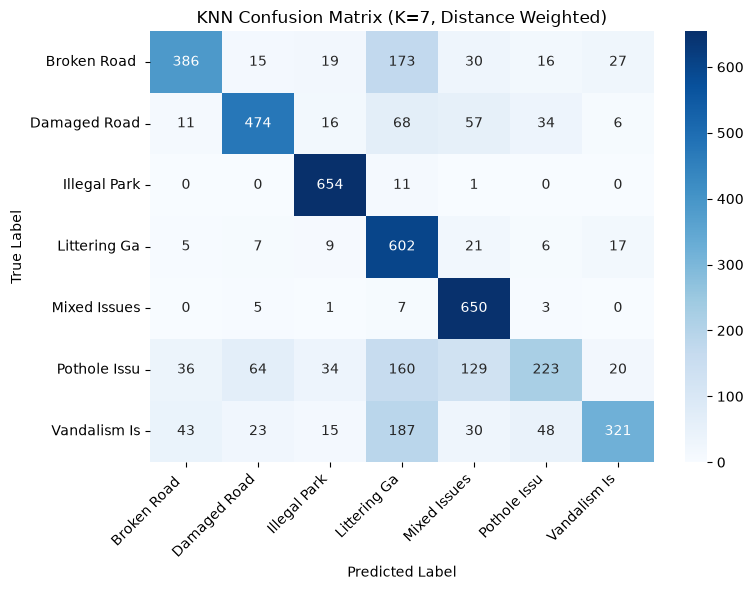

In [7]:
# Step 8: Final Model Evaluation and Confusion Matrix
best_knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
best_knn.fit(X_train_pca, y_train)
y_pred_knn = best_knn.predict(X_test_pca)

print("Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=[c[:15] for c in classes]))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[c[:12] for c in classes], yticklabels=[c[:12] for c in classes])
plt.title('KNN Confusion Matrix (K=7, Distance Weighted)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# Step 9: Overfitting Analysis & Conclusion
print("--- Overfitting Analysis ---")
print("When K = 1, training accuracy was 100.0%, showing complete memorization (overfitting).")
print(f"When K = 7 with distance weighting, test accuracy reached {accuracy_score(y_test, y_pred_knn)*100:.2f}%.")
print("KNN classifies based purely on distance to neighbors. It fits instantly but requires distance calculations on all training vectors during prediction.")


--- Overfitting Analysis ---
When K = 1, training accuracy was 100.0%, showing complete memorization (overfitting).
When K = 7 with distance weighting, test accuracy reached 70.97%.
KNN classifies based purely on distance to neighbors. It fits instantly but requires distance calculations on all training vectors during prediction.
